#### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
np.set_printoptions(precision=2)

#### Utility Functions

In [2]:
def sigmoid(u):
    u = np.maximum(u,-100)
    u = np.minimum(u,100)
    return 1/(1+np.exp(-u))

def ramp_sigmoid(x: torch.Tensor, k: float = 2.0) -> torch.Tensor:
    y = 0.5 + x / (2.0 * k)
    return torch.clamp(y, 0.0, 1.0)

def set_npseed(seed):
    np.random.seed(seed)


def set_torchseed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


#### Hyper parameters

In [3]:

class Args:
    def __init__(self):
        self.numlayer=4
        self.numnodes=1
        self.beta=100
        self.lr=0.2
        

In [4]:
args =  Args()

num_layer = args.numlayer
num_neuron = args.numnodes
beta = args.beta
lr=args.lr

saved_epochs = list(range(0,40000,100))#+list(range(5000,10001,5))#+list(range(1000,10001,50))
update_value_epochs = list(range(0,40000,200))
no_of_batches=1
weight_decay=0.0
num_hidden_nodes=[num_neuron]*num_layer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


cuda


#### Generate ODT dataset

In [5]:
def data_gen_decision_tree(num_data=1000, dim=2, seed=0, w_list=None, b_list=None, 
                            vals=None, num_levels=2):
    set_npseed(seed=seed)
    # Construct a complete decision tree with 2**num_levels-1 internal nodes, 
    # e.g. num_levels=2 means there are 3 internal nodes.
    # w_list, b_list is a list of size equal to num_internal_nodes
    # vals is a list of size equal to num_leaf_nodes, with values +1 or -1
    num_internal_nodes = 2**num_levels - 1
    num_leaf_nodes = 2**num_levels
    stats = np.zeros(num_internal_nodes+num_leaf_nodes)

    if vals is None:
        vals = np.arange(0,num_internal_nodes+num_leaf_nodes,1,dtype=np.int32)%2
        vals[:num_internal_nodes] = -99

    if w_list is None:
        w_list = np.random.standard_normal((num_internal_nodes, dim))
        w_list = w_list/np.linalg.norm(w_list, axis=1)[:, None]
        b_list = np.zeros((num_internal_nodes))
    w_list = np.zeros((num_internal_nodes, dim))
    for i in range(num_internal_nodes):
        w_list[i,i]=1.

    data_x = np.sign(np.random.standard_normal((num_data, dim)))    
    rand_matrix = np.random.rand(dim,dim)
    rand_orth, _ = np.linalg.qr(rand_matrix)
    data_x = -1 * data_x @ rand_orth

    data_x /= np.sqrt(np.sum(data_x**2, axis=1, keepdims=True))

    relevant_stats = data_x @ w_list.T + b_list
    

    curr_index = np.zeros(shape=(num_data), dtype=int)
    
    for level in range(num_levels):
        nodes_curr_level=list(range(2**level - 1,2**(level+1)-1  ))
        for el in nodes_curr_level:
            relevant_stats[:,el] += b_list[el]
        decision_variable = np.choose(curr_index, relevant_stats.T) 
        # Go down and right if wx+b>0 down and left otherwise. 
        # i.e. 0 -> 1 if w[0]x+b[0]<0 and 0->2 otherwise
        curr_index = (curr_index+1)*2 - (1-(decision_variable > 0))

    bound_dist = np.min(np.abs(relevant_stats), axis=1)
    thres = 0.0
    labels = vals[curr_index]
    data_x_pruned = data_x[bound_dist>thres]
    labels_pruned = labels[bound_dist>thres]
    relevant_stats = np.sign(data_x_pruned @ w_list.T + b_list)
    nodes_active = np.zeros((len(data_x_pruned),  num_internal_nodes+num_leaf_nodes), dtype=np.int32)
    for node in range(num_internal_nodes+num_leaf_nodes):
        if node==0:
            stats[node]=len(relevant_stats)
            nodes_active[:,0]=1
            continue
        parent = (node-1)//2
        nodes_active[:,node]=nodes_active[:,parent]
        right_child = node-(parent*2)-1 # 0 means left, 1 means right 1 has children 3,4
        if right_child==1:
            nodes_active[:,node] *= relevant_stats[:,parent]>0
        if right_child==0:
            nodes_active[:,node] *= relevant_stats[:,parent]<0		
        stats = nodes_active.sum(axis=0)
    return ((data_x_pruned, labels_pruned), (w_list, b_list, vals), stats, rand_orth)

num_data = 2000000
input_dim=100
seeds = np.random.random_integers(0,10000,100)

seeds = [75218]
for seed in seeds:
    ((data_x, labels), (w_list, b_list, vals), stats, rand_orth) = data_gen_decision_tree(
                                                dim=input_dim, seed=seed, num_levels=4,
                                                num_data=num_data)
    seed_set=seed
w_list_old = np.array(w_list)
b_list_old = np.array(b_list)

num_data = len(data_x)
num_train= num_data//2
num_vali = num_data//4
num_test = num_data//4
train_data = data_x[:num_train,:]
train_data_labels = labels[:num_train]

vali_data = data_x[num_train:num_train+num_vali,:]
vali_data_labels = labels[num_train:num_train+num_vali]

test_data = data_x[num_train+num_vali :,:]
test_data_labels = labels[num_train+num_vali :]

/tmp/ipykernel_2497239/3782073645.py:69: DeprecationWarning: This function is deprecated. Please call randint(0, 10000 + 1) instead
  seeds = np.random.random_integers(0,10000,100)


In [6]:

print(train_data.shape)
print(train_data_labels.shape)

print(test_data.shape)
print(test_data_labels.shape)

print(np.sum(train_data_labels==1))
print(np.sum(train_data_labels==0))

(1000000, 100)
(1000000,)
(500000, 100)
(500000,)
499674
500326


#### DLGN Class

In [7]:
class DLGN_FC(nn.Module):
    def __init__(self, input_dim=None, output_dim=None, num_hidden_nodes=[], beta=30, mode='pwc', device=device):		
        super(DLGN_FC, self).__init__()
        self.num_hidden_layers = len(num_hidden_nodes)
        self.beta=beta  # Soft gating parameter
        self.mode = mode
        self.num_nodes=[input_dim]+num_hidden_nodes+[output_dim]
        self.gating_layers=nn.ModuleList()
        self.value_layers=nn.Parameter(torch.randn([1]+[num_hidden_nodes[0]])/100.)
        self.num_layer = len(num_hidden_nodes)
        self.num_hidden_nodes = num_hidden_nodes
        for i in range(self.num_hidden_layers+1):
            if i!=self.num_hidden_layers:
                temp = nn.Linear(self.num_nodes[0], self.num_nodes[i+1], bias=False)
                self.gating_layers.append(temp)

    def set_parameters_with_mask(self, to_copy, parameter_masks):
        for (name, copy_param) in to_copy.named_parameters():
            copy_param = copy_param.clone().detach()
            orig_param  = self.state_dict()[name]
            if name in parameter_masks:
                param_mask = parameter_masks[name]>0
                orig_param[param_mask] = copy_param[param_mask]
            else:
                orig_param = copy_param.data.detach()     

    def return_gating_functions(self):
        effective_weights = []
        for i in range(self.num_hidden_layers):
            curr_weight = self.gating_layers[i].weight.detach().clone()
            effective_weights.append(curr_weight)
        return effective_weights
        # effective_weights (and effective biases) is a list of size num_hidden_layers
                            

    def forward(self, x):
        if self.mode=='pwc':
            values=[torch.ones(x.shape).to(device)]
        else:
            values=[x]
        
        for i in range(self.num_hidden_layers):
            fiber = [len(x)]+[1]*self.num_layer
            fiber[i+1] = self.num_hidden_nodes[i]
            fiber = tuple(fiber)
            gate_score = ramp_sigmoid( self.beta*
                  (x@self.gating_layers[i].weight.T))#/torch.norm(self.gating_layers[i].weight, dim=1, keepdim=True).T) # batch * m
            
            if i==0:
                cp = gate_score
            else:
                cp = cp*gate_score #batch * m
            
        return torch.sum(cp*self.value_layers, dim=1)

In [8]:
set_torchseed(71000)
DLGN_init= DLGN_FC(input_dim=input_dim, output_dim=1, num_hidden_nodes=num_hidden_nodes, beta=beta)
DLGN_init.value_layers.data=torch.ones_like(DLGN_init.value_layers.data)*0.1*(10)

bias = -3
mult = 1e-2

G0 = DLGN_init.gating_layers[0].weight.data
G1 = DLGN_init.gating_layers[1].weight.data
G2 = DLGN_init.gating_layers[2].weight.data
G3 = DLGN_init.gating_layers[3].weight.data

G0.copy_((torch.randint(2,(1,input_dim))*2 -1.)*0.0)
G1.copy_((torch.randint(2,(1,input_dim))*2 -1.)*0.0)
G2.copy_((torch.randint(2,(1,input_dim))*2 -1.)*0.0)
G3.copy_((torch.randint(2,(1,input_dim))*2 -1.)*0.0)


G0[0,7:15] += bias
G1[0,7:15] += bias
G2[0,7:15] += bias
G3[0,7:15] += bias

G1[0,7:11] *= 1.02
G2[0,7:11] *= 1.02
G3[0,7:11] *= 1.02

G2[0,7] *= 1.02
G3[0,8] *= 1.02

G0[0,7:15] -= bias
G1[0,7:15] -= bias
G2[0,7:15] -= bias
G3[0,7:15] -= bias

G0 *= mult
G1 *= mult
G2 *= mult
G3 *= mult

In [9]:
train_parameter_masks=dict() 
for name,parameter in DLGN_init.named_parameters():
    if "val" in name:
        train_parameter_masks[name]=torch.ones_like(parameter)*0
    elif "gat" in name and "0" in name:
        train_parameter_masks[name]=torch.ones_like(parameter)*1.
    else:
        train_parameter_masks[name]=torch.ones_like(parameter)*1.          

#### Train

In [10]:

def train_dlgn (DLGN_obj, train_data_curr,vali_data_curr,test_data_curr,
                train_labels_curr,test_labels_curr,vali_labels_curr,epochs=1,plot=False, val_freeze=False, parameter_mask = None, device=device
                ):
    
    DLGN_obj.to(device)

    criterion = nn.CrossEntropyLoss(reduction="mean")

    optimizer = optim.SGD(DLGN_obj.parameters(), lr=lr)
    # optimizer = optim.Adam(DLGN_obj.parameters(), lr =lr/50)

    train_data_torch = torch.Tensor(train_data_curr)
    vali_data_torch = torch.Tensor(vali_data_curr)
    test_data_torch = torch.Tensor(test_data_curr)

    train_labels_torch = torch.tensor(train_labels_curr, dtype=torch.int64)
    test_labels_torch = torch.tensor(test_labels_curr, dtype=torch.int64)
    vali_labels_torch = torch.tensor(vali_labels_curr, dtype=torch.int64)

    num_batches = no_of_batches
    batch_size = len(train_data_curr)//num_batches
    losses=[]
    DLGN_obj_store = []
    best_vali_error = len(vali_labels_curr)
    DLGN_obj_store.append(deepcopy(DLGN_obj))

    debug_models= []
    train_losses = []
    for epoch in tqdm(range(epochs)):
        optimizer.zero_grad()
        for batch_start in range(0,len(train_data_curr),batch_size):
            if (batch_start+batch_size)>len(train_data_curr):
                break			
            inputs = train_data_torch[batch_start:batch_start+batch_size]
            targets = train_labels_torch[batch_start:batch_start+batch_size].reshape(batch_size)
            inputs = inputs.to(device)
            targets = targets.to(device)
            preds = DLGN_obj(inputs).reshape(-1,1)
            outputs = torch.cat((-1*preds, preds), dim=1)
            loss = criterion(outputs, targets)
            train_losses.append(loss.data.cpu().numpy())			
            loss.backward()
        if parameter_mask is not None:
            for name,parameter in DLGN_obj.named_parameters():
                    parameter.grad *= parameter_mask[name].to(device)        
        
        optimizer.step()
        DLGN_obj_store.append(deepcopy(DLGN_obj))
    if plot:
        plt.plot(train_losses)
        print("Train loss is: ",train_losses[-1])

    inputs = test_data_torch
    targets = test_labels_torch
    inputs = inputs.to(device)
    targets = targets.to(device)
    preds = DLGN_obj(inputs).reshape(-1,1)
    outputs = torch.cat((-1*preds, preds), dim=1)
    loss = criterion(outputs, targets)
    print("Test loss is: ",loss)
    return DLGN_obj_store, train_losses

100%|██████████| 1000/1000 [05:31<00:00,  3.02it/s]


Train loss is:  0.65424854
Test loss is:  tensor(0.6541, device='cuda:0', grad_fn=<NllLossBackward0>)


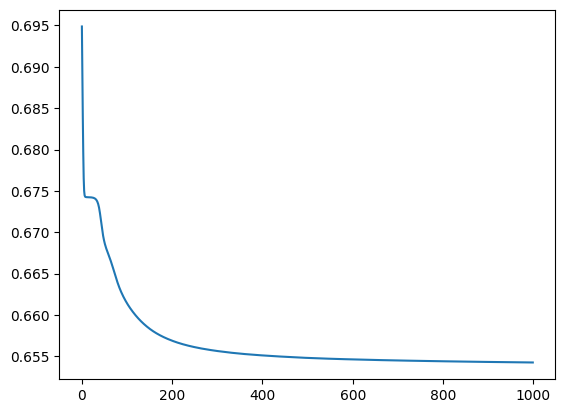

In [11]:
epochs=1000
DLGN_obj_store, train_losses = train_dlgn(train_data_curr=train_data,
                            vali_data_curr=vali_data,
                            test_data_curr=test_data,
                            train_labels_curr=train_data_labels,
                            vali_labels_curr=vali_data_labels,
                            test_labels_curr=test_data_labels,
                            DLGN_obj=deepcopy(DLGN_init),
                            epochs=epochs,
                            plot=True,
                            val_freeze=False, 
                            parameter_mask=train_parameter_masks
                            )


#### Visualize

In [12]:
ew_store_straight_list = []
val_store_straight_list = []
ew_store = np.zeros((len(DLGN_obj_store),num_layer,num_neuron,input_dim))
val_store = np.zeros((len(DLGN_obj_store),num_neuron))
for i,model in enumerate(DLGN_obj_store):
    ew = DLGN_obj_store[i].return_gating_functions()
    ew_store[i,0] = ew[0].cpu().numpy()
    ew_store[i,1] = ew[1].cpu().numpy()
    ew_store[i,2] = ew[2].cpu().numpy()
    ew_store[i,3] = ew[3].cpu().numpy()

    val_store[i] = model.value_layers.detach().clone().cpu().numpy()
ew_store_straight_list.append(ew_store)
val_store_straight_list.append(val_store)


In [13]:
ew_store_straight = np.array(ew_store_straight_list).reshape(-1,num_layer,1,input_dim)
val_store_straight = np.array(val_store_straight_list).reshape(-1,1)

In [14]:
print(np.abs(ew_store_straight[-1,:,0,:]).argmax(axis=1))
np.set_printoptions(precision=4)
print(ew_store_straight[0,:,0,7:16])
print(val_store_straight[0])

[0 1 7 8]
[[ 0.      0.      0.      0.      0.      0.      0.      0.     -0.    ]
 [-0.0006 -0.0006 -0.0006 -0.0006  0.      0.      0.      0.     -0.    ]
 [-0.0012 -0.0006 -0.0006 -0.0006  0.      0.      0.      0.      0.    ]
 [-0.0006 -0.0012 -0.0006 -0.0006  0.      0.      0.      0.      0.    ]]
[1.]


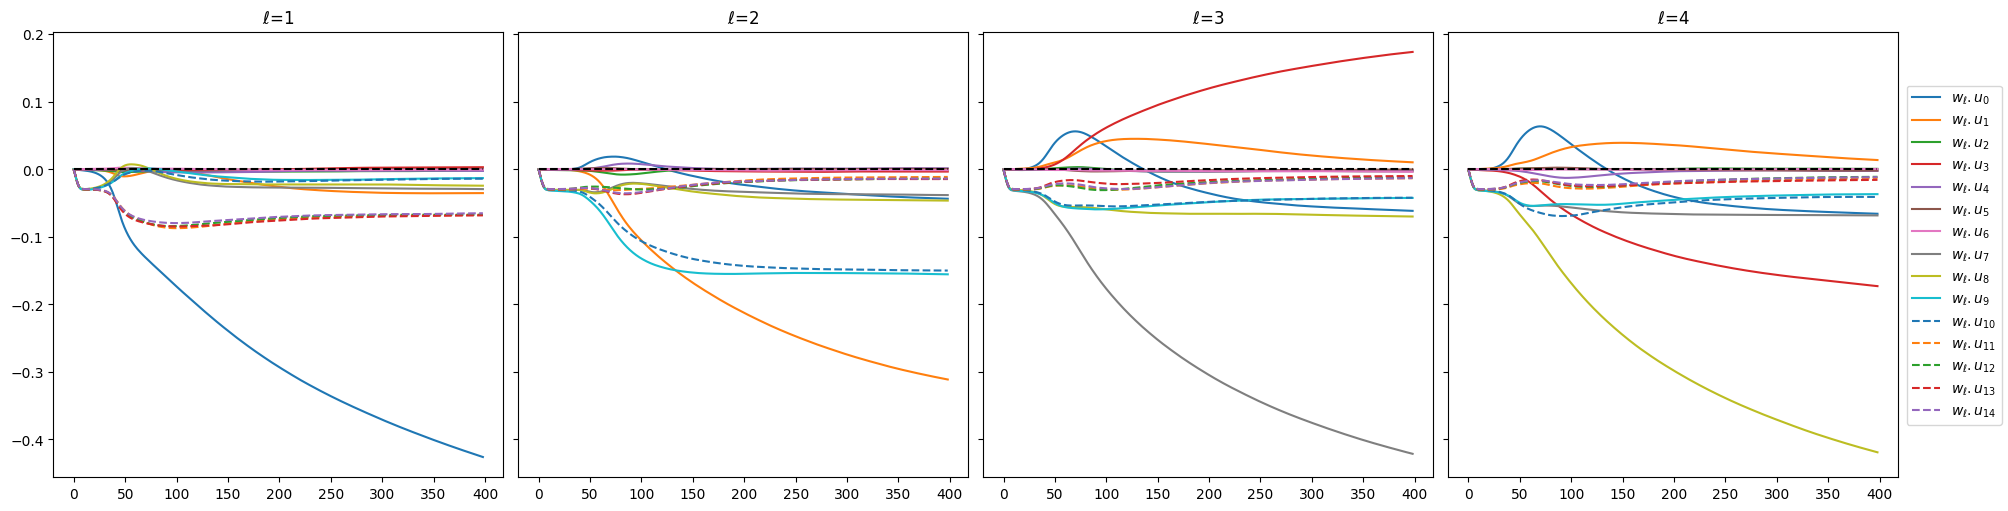

In [ ]:

k=0
start = 0
end= 400
lines_plot = list(range(0,15)) 
fig, axs = plt.subplots(1,4, sharey="row", figsize=(20,5),  layout="constrained")
for l in range(num_layer):
    axs[l].set_title(fr"$\ell$={l+1}")
    for i in lines_plot:
        label = fr"$w_\ell.u_{{{i}}}$" if l == 0 else None

        if i>=15:
            axs[l].plot(range(start,end-1),ew_store_straight[start:end-1,l,k,i], "k--", linewidth =1.)
        elif i>=10:
            axs[l].plot(range(start,end-1),ew_store_straight[start:end-1,l,k,i], label=label, ls="dashed")
        else:
            axs[l].plot(range(start,end-1),ew_store_straight[start:end-1,l,k,i], label=label, ls="solid")

    axs[l].plot([start,end-2],[0,0],'k--')

# Collect handles and labels from all axes
handles_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
handles, labels = [sum(lol, []) for lol in zip(*handles_labels)]

# Add a single legend for the figure
fig.legend(handles, labels, loc='outside right center', ncol=1)
# fig.suptitle("Parameter components along ODT node vectors vs training epoch")

fig, axs = plt.subplots(1,4,sharey="row",figsize=(20,5),  layout="constrained")
for l in range(num_layer):
    # plt.ylim([-0.001,0.001])
    axs[l].set_title(fr"$\ell$={l+1}")
    # plt.yscale("symlog", linthresh=0.01)
    # plt.xscale("log")
    # axs[l].set_xscale("log")
    for i in lines_plot:
        # plt.plot([start,end],[0.02,0.02],ls="dotted", lw=1)
        label = fr"$\Delta w_\ell.u_{{{i}}}$" if l == 0 else None
        if i>=15:
            axs[l].plot(range(start,end-1),ew_store_straight[start+1:end,l,k,i]-ew_store_straight[start:end-1,l,k,i], "k--", linewidth =1. )
        elif i>=10:
            axs[l].plot(range(start,end-1),ew_store_straight[start+1:end,l,k,i]-ew_store_straight[start:end-1,l,k,i], label=label, ls="dashed")
        else:
            axs[l].plot(range(start,end-1),ew_store_straight[start+1:end,l,k,i]-ew_store_straight[start:end-1,l,k,i], label=label, ls="solid")

    axs[l].plot([start,end-2],[0,0],'k--')
# Collect handles and labels from all axes
handles_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
handles, labels = [sum(lol, []) for lol in zip(*handles_labels)]
fig.suptitle("Change in parameter components along ODT node vectors vs training epoch")

fig.legend(handles, labels, loc='outside right center', ncol=1)

plt.show()

In [ ]:
# import matplotlib.pyplot as plt

# params = {
#     'axes.titlesize': 20,     # Font size for the plot title (axs[l].set_title)
#     'axes.labelsize': 20,     # Font size for x and y labels
#     'xtick.labelsize': 20,    # Font size for x-axis tick labels
#     'ytick.labelsize': 20,    # Font size for y-axis tick labels
#     'legend.fontsize': 20,    # Font size for the legend
#     'font.family': 'serif',   
#     'font.size': 20           
# }
# plt.rcParams.update(params)

# # === User selectable: indices to highlight ===
# important_idxs = [0, 1, 7, 8, 3]  # change as needed, order determines color assignment

# k = 0
# start = 0
# end = 400
# lines_plot = list(range(0, 15))

# # fetch default color cycle to assign distinct colors to important indices
# color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

# fig, axs = plt.subplots(1, 4, sharey="row", figsize=(20, 5), layout="constrained")

# # first figure: ew_store_straight values
# for l in range(num_layer):
#     axs[l].set_title(fr"$\ell$={l+1}")
#     # used to add a single legend entry for all gray lines (only once)
#     gray_legend_added = False
#     for i in lines_plot:
#         # label only for layer 0 as in your original code
#         label = fr"$w_\ell.u_{{{i}}}$" if (l == 0 and i in important_idxs) else None

#         # determine linestyle as before: i>=15 -> dashed black, i>=10 -> dashed, else solid
#         if i >= 15:
#             ls = '--'
#         elif i >= 10:
#             ls = 'dashed'
#         else:
#             ls = 'solid'

#         if i in important_idxs:
#             color = color_cycle[important_idxs.index(i) % len(color_cycle)]
#             axs[l].plot(range(start, end - 1),
#                         ew_store_straight[start:end - 1, l, k, i],
#                         label=label,
#                         linestyle=ls,
#                         linewidth=2.0,
#                         color=color)
#         else:
#             # gray, de-emphasized
#             # add a single legend entry for all gray indices (only for layer 0)
#             gray_label = "w_l. u_*" if l == 0 and not gray_legend_added else None
#             if gray_label is not None:
#                 gray_legend_added = True
#             axs[l].plot(range(start, end - 1),
#                         ew_store_straight[start:end - 1, l, k, i],
#                         label=gray_label,
#                         linestyle=ls,
#                         linewidth=1.5,
#                         color='lightgray',
#                         alpha=0.9)

#     axs[l].plot([start, end - 2], [0, 0], 'k--')

# handles_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
# handles, labels = [sum(lol, []) for lol in zip(*handles_labels)]

# seen = {}
# unique_handles = []
# unique_labels = []
# for h, lbl in zip(handles, labels):
#     if not lbl or lbl == '':
#         continue
#     if lbl not in seen:
#         seen[lbl] = True
#         unique_handles.append(h)
#         unique_labels.append(lbl)

# fig.legend(unique_handles, unique_labels, loc='center left', bbox_to_anchor=(1.02, 0.5), ncol=1)
# plt.savefig('figures/parameter_trajectory2_0178.pdf', format='pdf', bbox_inches='tight')

# # === second figure: changes (delta) ===
# fig, axs = plt.subplots(1, 4, sharey="row", figsize=(20, 5), layout="constrained")
# for l in range(num_layer):
#     axs[l].set_title(fr"$\ell$={l+1}")
#     gray_legend_added = False
#     for i in lines_plot:
#         label = fr"$\Delta w_\ell.u_{{{i}}}$" if (l == 0 and i in important_idxs) else None

#         if i >= 15:
#             ls = '--'
#         elif i >= 10:
#             ls = 'dashed'
#         else:
#             ls = 'solid'

#         delta = ew_store_straight[start + 1:end, l, k, i] - ew_store_straight[start:end - 1, l, k, i]

#         if i in important_idxs:
#             color = color_cycle[important_idxs.index(i) % len(color_cycle)]
#             axs[l].plot(range(start, end - 1),
#                         delta,
#                         label=label,
#                         linestyle=ls,
#                         linewidth=1.5,
#                         color=color)
#         else:
#             gray_label = "Δw_l. u_*" if l == 0 and not gray_legend_added else None
#             if gray_label is not None:
#                 gray_legend_added = True
#             axs[l].plot(range(start, end - 1),
#                         delta,
#                         label=gray_label,
#                         linestyle=ls,
#                         linewidth=1.0,
#                         color='lightgray',
#                         alpha=0.9)

#     axs[l].plot([start, end - 2], [0, 0], 'k--')

# handles_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
# handles, labels = [sum(lol, []) for lol in zip(*handles_labels)]

# seen = {}
# unique_handles = []
# unique_labels = []
# for h, lbl in zip(handles, labels):
#     if not lbl or lbl == '':
#         continue
#     if lbl not in seen:
#         seen[lbl] = True
#         unique_handles.append(h)
#         unique_labels.append(lbl)

# fig.suptitle("Change in parameter components along ODT node vectors vs training epoch")
# fig.legend(unique_handles, unique_labels, loc='center left', bbox_to_anchor=(1.02, 0.5), ncol=1)
# plt.savefig('figures/gradient_trajectory2_0178.pdf', format='pdf')

# plt.show()
